# Swissgrid probabilistic-wind and PRA numerical demo

This notebook turns line-sample wind forecasts into concise, report-ready
numerical evidence. It computes mapping-quality diagnostics, network wind
statistics, the most exposed branches, threshold exceedances and persistence,
and optional probabilistic reliability metrics (ENS, VaR and CVaR).

**Safe default:** the notebook runs with synthetic data so every cell can be
tested immediately. Synthetic outputs are labelled `DEMO — DO NOT QUOTE`.
Set `CFG.use_synthetic_demo = False` and update the two input paths to analyse real
exports.

Run from Jupyter with **Kernel → Restart Kernel and Run All Cells**. The last
section prints the output folder and saves CSV, JSON, LaTeX, PNG and TXT files.


In [1]:
from __future__ import annotations

import json
import math
import shutil
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # The file also remains runnable as a normal Python script.
    display = print

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root(start: Path) -> Path:
    """Find a sensible repository root without requiring a fixed notebook location."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / ".git").exists() or any(
            (candidate / marker).exists()
            for marker in ("data", "project_sources", "scheduler_monolitic", "scheduler_clustered")
        ):
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())


@dataclass
class AnalysisConfig:
    use_synthetic_demo: bool = True
    wind_csv: str = "data/weather/swissgrid_line_sample_forecasts.csv"
    pra_csv: str = "data/weather/swissgrid_pra_scenarios.csv"
    output_dir: str = "outputs/wind_pra_analysis"
    run_label: str = "swissgrid_2026"
    forecast_horizon_h: int = 32
    maximum_matching_distance_km: float = 25.0
    exposure_threshold_ms: float = 20.0
    top_n_lines: int = 8
    synthetic_lines: int = 46
    synthetic_samples_per_line: int = 7
    synthetic_pra_scenarios: int = 6000
    cvar_confidence: float = 0.95
    random_seed: int = 20260915


CFG = AnalysisConfig()
WIND_PATH = PROJECT_ROOT / CFG.wind_csv
PRA_PATH = PROJECT_ROOT / CFG.pra_csv

print(f"Project root : {PROJECT_ROOT}")
print(f"Data mode    : {'SYNTHETIC DEMO — DO NOT QUOTE' if CFG.use_synthetic_demo else 'REAL INPUT FILES'}")
print(f"Wind input   : {WIND_PATH}")
print(f"PRA input    : {PRA_PATH}")


Project root : C:\Users\roberto.rocchetta\Documents\GitHub\PROPER
Data mode    : SYNTHETIC DEMO — DO NOT QUOTE
Wind input   : C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\weather\swissgrid_line_sample_forecasts.csv
PRA input    : C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\weather\swissgrid_pra_scenarios.csv


## Expected real-data schemas

The wind CSV contains one record for each **line × spatial sample × lead
hour**. Canonical columns are:

| Required | Optional |
|---|---|
| `line_id`, `sample_id`, `lead_hour` | `meteo_point_id` |
| `match_distance_km` | `matched` (derived from distance if absent) |
| `gust_q10_ms`, `gust_main_ms`, `gust_q90_ms` | `wind_direction_deg`, `line_bearing_deg` |
|  | `crosswind_q10_ms`, `crosswind_main_ms`, `crosswind_q90_ms` |

Crosswind columns are calculated when wind direction and line bearing are
available. Otherwise, crosswind-specific KPIs are reported as unavailable;
gust speed is never silently substituted for transverse gust.

The optional PRA CSV contains one record per Monte Carlo scenario and
condition: `condition`, `scenario_id`, `line_failures`, `ens_mwh`, and
optionally `probability`, `dns_mw`, and `operating_cost_eur`. If the PRA file
is absent, the wind-only analysis still runs.


In [2]:
COLUMN_ALIASES = {
    "line_id": ["line_id", "branch_id", "branch", "line", "element_id"],
    "sample_id": ["sample_id", "sample", "sample_idx", "line_sample"],
    "lead_hour": ["lead_hour", "horizon_hour", "forecast_hour", "lead", "hour"],
    "meteo_point_id": ["meteo_point_id", "point_key", "weather_point", "meteo_key"],
    "match_distance_km": ["match_distance_km", "distance_km", "matching_distance_km", "nearest_distance_km"],
    "matched": ["matched", "is_matched", "match_ok"],
    "gust_q10_ms": ["gust_q10_ms", "wind_gust_q10_ms", "gust_p10_ms", "gust_q10"],
    "gust_main_ms": ["gust_main_ms", "wind_gust_main_ms", "gust_q50_ms", "gust_median_ms", "gust_main"],
    "gust_q90_ms": ["gust_q90_ms", "wind_gust_q90_ms", "gust_p90_ms", "gust_q90"],
    "crosswind_q10_ms": ["crosswind_q10_ms", "transverse_gust_q10_ms", "gust_perp_q10_ms"],
    "crosswind_main_ms": ["crosswind_main_ms", "transverse_gust_main_ms", "gust_perp_main_ms"],
    "crosswind_q90_ms": ["crosswind_q90_ms", "transverse_gust_q90_ms", "gust_perp_q90_ms"],
    "wind_direction_deg": ["wind_direction_deg", "wind_dir_deg", "direction_deg"],
    "line_bearing_deg": ["line_bearing_deg", "branch_bearing_deg", "bearing_deg"],
}


def normalise_name(name: str) -> str:
    return "_".join(str(name).strip().lower().replace("/", "_").replace("-", "_").split())


def canonicalise_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Map common export names to the canonical schema without overwriting fields."""
    frame = frame.copy()
    normalised = {normalise_name(column): column for column in frame.columns}
    renames = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in frame.columns:
            continue
        for alias in aliases:
            source = normalised.get(normalise_name(alias))
            if source is not None:
                renames[source] = canonical
                break
    return frame.rename(columns=renames)


def as_boolean(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    truthy = {"true", "1", "yes", "y", "matched", "ok"}
    return series.astype(str).str.strip().str.lower().isin(truthy)


def validate_wind_data(frame: pd.DataFrame, cfg: AnalysisConfig) -> tuple[pd.DataFrame, list[str]]:
    frame = canonicalise_columns(frame)
    messages: list[str] = []
    required = {
        "line_id", "sample_id", "lead_hour", "match_distance_km",
        "gust_q10_ms", "gust_main_ms", "gust_q90_ms",
    }
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise ValueError(
            "Wind input is missing required columns: " + ", ".join(missing)
            + ". Edit COLUMN_ALIASES if your export uses different names."
        )

    numeric = [
        "lead_hour", "match_distance_km", "gust_q10_ms", "gust_main_ms", "gust_q90_ms",
        "crosswind_q10_ms", "crosswind_main_ms", "crosswind_q90_ms",
        "wind_direction_deg", "line_bearing_deg",
    ]
    for column in numeric:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")

    if "matched" in frame.columns:
        frame["matched"] = as_boolean(frame["matched"])
    else:
        frame["matched"] = frame["match_distance_km"] <= cfg.maximum_matching_distance_km
        messages.append("Column 'matched' was derived from maximum_matching_distance_km.")

    crosswind_columns = ["crosswind_q10_ms", "crosswind_main_ms", "crosswind_q90_ms"]
    if not set(crosswind_columns).issubset(frame.columns):
        if {"wind_direction_deg", "line_bearing_deg"}.issubset(frame.columns):
            relative = np.deg2rad(frame["wind_direction_deg"] - frame["line_bearing_deg"])
            factor = np.abs(np.sin(relative))
            for suffix in ("q10", "main", "q90"):
                frame[f"crosswind_{suffix}_ms"] = frame[f"gust_{suffix}_ms"] * factor
            messages.append("Crosswind gusts were calculated from wind direction and line bearing.")
        else:
            for column in crosswind_columns:
                frame[column] = np.nan
            messages.append("Crosswind KPIs are unavailable: provide crosswind values or direction and bearing.")

    frame = frame.loc[frame["lead_hour"].between(1, cfg.forecast_horizon_h)].copy()
    essential_numeric = ["lead_hour", "match_distance_km", "gust_q10_ms", "gust_main_ms", "gust_q90_ms"]
    bad_rows = frame[essential_numeric].isna().any(axis=1)
    if bad_rows.any():
        messages.append(f"Dropped {int(bad_rows.sum())} rows with invalid required numeric values.")
        frame = frame.loc[~bad_rows].copy()

    if frame.empty:
        raise ValueError("No valid wind records remain after validation and horizon filtering.")
    if (frame[["gust_q10_ms", "gust_main_ms", "gust_q90_ms"]] < 0).any().any():
        raise ValueError("Wind speeds must be non-negative.")
    if not ((frame["gust_q10_ms"] <= frame["gust_main_ms"]) & (frame["gust_main_ms"] <= frame["gust_q90_ms"])).all():
        messages.append("Some gust quantiles are not ordered q10 <= main <= q90; inspect the source export.")

    frame["line_id"] = frame["line_id"].astype(str)
    frame["sample_id"] = frame["sample_id"].astype(str)
    frame["lead_hour"] = frame["lead_hour"].astype(int)
    return frame, messages


def validate_pra_data(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    aliases = {
        "condition": ["condition", "case", "scenario_set", "forecast_case", "method"],
        "scenario_id": ["scenario_id", "sample_id", "mc_scenario", "iteration"],
        "line_failures": ["line_failures", "failed_lines", "n_failures"],
        "ens_mwh": ["ens_mwh", "energy_not_served_mwh", "eens_mwh"],
        "dns_mw": ["dns_mw", "demand_not_served_mw", "load_shed_mw"],
        "operating_cost_eur": ["operating_cost_eur", "cost_eur", "operating_cost"],
        "probability": ["probability", "weight", "scenario_probability"],
    }
    frame = frame.copy()
    normalised = {normalise_name(column): column for column in frame.columns}
    renames = {}
    for canonical, names in aliases.items():
        if canonical not in frame.columns:
            for name in names:
                if normalise_name(name) in normalised:
                    renames[normalised[normalise_name(name)]] = canonical
                    break
    frame = frame.rename(columns=renames)
    required = {"condition", "scenario_id", "line_failures", "ens_mwh"}
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise ValueError("PRA input is missing required columns: " + ", ".join(missing))
    for column in ["line_failures", "ens_mwh", "dns_mw", "operating_cost_eur", "probability"]:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=["line_failures", "ens_mwh"]).copy()
    if "probability" not in frame.columns:
        frame["probability"] = frame.groupby("condition")["scenario_id"].transform(lambda s: 1.0 / len(s))
    totals = frame.groupby("condition")["probability"].transform("sum")
    frame["probability"] = frame["probability"] / totals
    return frame, []


## Synthetic demonstration data

The generator below is deliberately transparent. It creates plausible-looking
line, sample and time variation only to exercise the workflow. It is **not** a
Swissgrid result and cannot be cited in the report.


In [3]:
def make_synthetic_wind(cfg: AnalysisConfig) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.random_seed)
    rows = []
    hours = np.arange(1, cfg.forecast_horizon_h + 1)
    synoptic = 2.8 * np.sin((hours - 5) / 7.0) + 5.2 * np.exp(-0.5 * ((hours - 22) / 5.2) ** 2)

    for line_index in range(cfg.synthetic_lines):
        line_id = f"L{line_index + 1:03d}"
        bearing = rng.uniform(0, 180)
        base = rng.uniform(7.0, 13.5)
        exposure = rng.lognormal(mean=0.0, sigma=0.24)
        for sample_index in range(cfg.synthetic_samples_per_line):
            distance = min(float(rng.gamma(shape=2.0, scale=5.0)), 48.0)
            if rng.random() < 0.025:
                distance = rng.uniform(cfg.maximum_matching_distance_km + 1, 45)
            point_id = f"MET-{rng.integers(1, 160):03d}"
            spatial = rng.normal(0, 0.8)
            phase = rng.uniform(-0.6, 0.6)
            for hour, weather in zip(hours, synoptic):
                median = max(0.2, (base + weather + spatial + phase * math.sin(hour / 4)) * exposure)
                spread = 1.4 + 0.11 * median + rng.uniform(0.0, 0.9)
                q10 = max(0.0, median - 0.82 * spread)
                q90 = median + spread
                wind_direction = (245 + 24 * math.sin(hour / 8) + rng.normal(0, 9)) % 360
                factor = abs(math.sin(math.radians(wind_direction - bearing)))
                rows.append({
                    "line_id": line_id,
                    "sample_id": sample_index + 1,
                    "lead_hour": int(hour),
                    "meteo_point_id": point_id,
                    "match_distance_km": distance,
                    "matched": distance <= cfg.maximum_matching_distance_km,
                    "gust_q10_ms": q10,
                    "gust_main_ms": median,
                    "gust_q90_ms": q90,
                    "wind_direction_deg": wind_direction,
                    "line_bearing_deg": bearing,
                    "crosswind_q10_ms": q10 * factor,
                    "crosswind_main_ms": median * factor,
                    "crosswind_q90_ms": q90 * factor,
                })
    return pd.DataFrame(rows)


def make_synthetic_pra(wind: pd.DataFrame, cfg: AnalysisConfig) -> pd.DataFrame:
    """Illustrative Monte Carlo propagation from line gust peaks to failures and ENS."""
    rng = np.random.default_rng(cfg.random_seed + 1)
    peaks = wind.groupby("line_id")[["gust_main_ms", "gust_q90_ms"]].max()
    lines = peaks.index.to_numpy()
    consequence_mwh = rng.lognormal(mean=np.log(42), sigma=0.65, size=len(lines))
    base_cost = 1_480_000.0
    conditions = {
        "Historical baseline": np.full(len(lines), 10.0),
        "Forecast central": peaks["gust_main_ms"].to_numpy(),
        "Forecast q90": peaks["gust_q90_ms"].to_numpy(),
    }
    records = []
    for condition, gust in conditions.items():
        failure_probability = np.clip(0.00055 * np.exp((gust - 10.0) / 4.8), 0, 0.16)
        failures = rng.random((cfg.synthetic_pra_scenarios, len(lines))) < failure_probability
        severity = rng.lognormal(mean=0.0, sigma=0.28, size=(cfg.synthetic_pra_scenarios, len(lines)))
        ens = (failures * consequence_mwh * severity).sum(axis=1)
        line_failures = failures.sum(axis=1)
        dns = ens / rng.uniform(1.8, 4.5, size=cfg.synthetic_pra_scenarios)
        operating_cost = base_cost + 5_800 * line_failures + 215 * ens + rng.normal(0, 8_000, cfg.synthetic_pra_scenarios)
        for scenario_id in range(cfg.synthetic_pra_scenarios):
            records.append({
                "condition": condition,
                "scenario_id": scenario_id + 1,
                "line_failures": int(line_failures[scenario_id]),
                "ens_mwh": float(ens[scenario_id]),
                "dns_mw": float(dns[scenario_id]),
                "operating_cost_eur": float(operating_cost[scenario_id]),
                "probability": 1.0 / cfg.synthetic_pra_scenarios,
            })
    return pd.DataFrame(records)


In [4]:
messages: list[str] = []

if CFG.use_synthetic_demo:
    wind_raw = make_synthetic_wind(CFG)
    wind, wind_messages = validate_wind_data(wind_raw, CFG)
    pra_raw = make_synthetic_pra(wind, CFG)
    pra, pra_messages = validate_pra_data(pra_raw)
    data_label = "SYNTHETIC DEMO — DO NOT QUOTE"
else:
    if not WIND_PATH.exists():
        raise FileNotFoundError(
            f"Wind input not found: {WIND_PATH}\n"
            "Set CFG.wind_csv to your export or enable CFG.use_synthetic_demo."
        )
    wind, wind_messages = validate_wind_data(pd.read_csv(WIND_PATH), CFG)
    if PRA_PATH.exists():
        pra, pra_messages = validate_pra_data(pd.read_csv(PRA_PATH))
    else:
        pra, pra_messages = None, [f"No PRA file found at {PRA_PATH}; reliability KPIs were skipped."]
    data_label = "REAL INPUT FILES"

messages.extend(wind_messages)
messages.extend(pra_messages)
print(f"Loaded {len(wind):,} valid wind records across {wind['line_id'].nunique()} lines.")
if pra is not None:
    print(f"Loaded {len(pra):,} PRA scenario records across {pra['condition'].nunique()} conditions.")
for message in messages:
    print("NOTE:", message)


Loaded 10,304 valid wind records across 46 lines.
Loaded 18,000 PRA scenario records across 3 conditions.


## KPI calculation


In [5]:
def longest_true_run(values: pd.Series) -> int:
    longest = current = 0
    for value in values.astype(bool):
        current = current + 1 if value else 0
        longest = max(longest, current)
    return longest


def weighted_quantile(values: pd.Series, weights: pd.Series, quantile: float) -> float:
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) / weights.sum()
    return float(values[np.searchsorted(cumulative, quantile, side="left")])


def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    return float(np.average(np.asarray(values, dtype=float), weights=np.asarray(weights, dtype=float)))


def weighted_cvar(values: pd.Series, weights: pd.Series, confidence: float) -> float:
    """Rockafellar–Uryasev expected shortfall, robust to probability mass at VaR."""
    values_array = np.asarray(values, dtype=float)
    weights_array = np.asarray(weights, dtype=float)
    weights_array = weights_array / weights_array.sum()
    var = weighted_quantile(values, weights, confidence)
    return float(var + np.sum(weights_array * np.maximum(values_array - var, 0.0)) / (1.0 - confidence))


def analyse_wind(wind: pd.DataFrame, cfg: AnalysisConfig):
    target_map = (
        wind.groupby(["line_id", "sample_id"], as_index=False)
        .agg(match_distance_km=("match_distance_km", "median"), matched=("matched", "all"))
    )
    matched_distances = target_map.loc[target_map["matched"], "match_distance_km"]
    mapping = {
        "wind_exposed_lines": int(wind["line_id"].nunique()),
        "line_sample_targets": int(len(target_map)),
        "matched_targets": int(target_map["matched"].sum()),
        "matched_targets_pct": float(100 * target_map["matched"].mean()),
        "median_match_distance_km": float(matched_distances.median()),
        "p95_match_distance_km": float(matched_distances.quantile(0.95)),
        "max_match_distance_km": float(matched_distances.max()),
        "forecast_horizon_h": int(wind["lead_hour"].max()),
    }

    aggregations = {
        "gust_q10_ms": "mean",
        "gust_main_ms": "mean",
        "gust_q90_ms": ["mean", "max"],
        "crosswind_q90_ms": "max",
    }
    line_hour = wind.groupby(["line_id", "lead_hour"]).agg(aggregations)
    line_hour.columns = ["_".join(parts).rstrip("_") for parts in line_hour.columns.to_flat_index()]
    line_hour = line_hour.rename(columns={
        "gust_q10_ms_mean": "gust_q10_mean_ms",
        "gust_main_ms_mean": "gust_main_mean_ms",
        "gust_q90_ms_mean": "gust_q90_mean_ms",
        "gust_q90_ms_max": "gust_q90_max_ms",
        "crosswind_q90_ms_max": "crosswind_q90_max_ms",
    }).reset_index()
    line_hour["q90_q10_spread_ms"] = line_hour["gust_q90_mean_ms"] - line_hour["gust_q10_mean_ms"]
    line_hour["above_threshold"] = line_hour["gust_q90_max_ms"] >= cfg.exposure_threshold_ms

    peak_index = line_hour["gust_q90_max_ms"].idxmax()
    peak = line_hour.loc[peak_index]
    forecast = {
        "network_q90_median_ms": float(line_hour["gust_q90_mean_ms"].median()),
        "network_q90_p95_ms": float(line_hour["gust_q90_mean_ms"].quantile(0.95)),
        "network_q90_max_ms": float(peak["gust_q90_max_ms"]),
        "network_q90_max_line": str(peak["line_id"]),
        "network_q90_max_lead_hour": int(peak["lead_hour"]),
        "median_q90_q10_spread_ms": float(line_hour["q90_q10_spread_ms"].median()),
        "max_q90_q10_spread_ms": float(line_hour["q90_q10_spread_ms"].max()),
        "line_hours_above_threshold": int(line_hour["above_threshold"].sum()),
        "lines_above_threshold": int(line_hour.loc[line_hour["above_threshold"], "line_id"].nunique()),
        "lines_above_threshold_pct": float(
            100 * line_hour.loc[line_hour["above_threshold"], "line_id"].nunique() / line_hour["line_id"].nunique()
        ),
    }
    if line_hour["crosswind_q90_max_ms"].notna().any():
        cross_peak = line_hour.loc[line_hour["crosswind_q90_max_ms"].idxmax()]
        forecast.update({
            "max_crosswind_q90_ms": float(cross_peak["crosswind_q90_max_ms"]),
            "max_crosswind_q90_line": str(cross_peak["line_id"]),
            "max_crosswind_q90_lead_hour": int(cross_peak["lead_hour"]),
        })
    else:
        forecast.update({
            "max_crosswind_q90_ms": None,
            "max_crosswind_q90_line": None,
            "max_crosswind_q90_lead_hour": None,
        })

    persistence = (
        line_hour.sort_values(["line_id", "lead_hour"])
        .groupby("line_id")["above_threshold"]
        .apply(longest_true_run)
        .rename("longest_exceedance_h")
    )
    forecast["maximum_exceedance_persistence_h"] = int(persistence.max())

    peak_rows = line_hour.loc[line_hour.groupby("line_id")["gust_q90_max_ms"].idxmax()].copy()
    match_info = target_map.groupby("line_id").agg(
        spatial_samples=("sample_id", "nunique"),
        matched_samples=("matched", "sum"),
        median_match_distance_km=("match_distance_km", "median"),
        max_match_distance_km=("match_distance_km", "max"),
    )
    top_lines = (
        peak_rows.set_index("line_id")
        .join(match_info)
        .join(persistence)
        .sort_values("gust_q90_max_ms", ascending=False)
        .head(cfg.top_n_lines)
        .reset_index()
        [[
            "line_id", "spatial_samples", "matched_samples", "median_match_distance_km",
            "gust_main_mean_ms", "gust_q90_max_ms", "crosswind_q90_max_ms",
            "lead_hour", "longest_exceedance_h",
        ]]
        .rename(columns={"lead_hour": "peak_lead_hour"})
    )
    return mapping, forecast, line_hour, top_lines


def analyse_pra(pra: pd.DataFrame, confidence: float) -> pd.DataFrame:
    rows = []
    for condition, group in pra.groupby("condition", sort=False):
        weights = group["probability"]
        var_ens = weighted_quantile(group["ens_mwh"], weights, confidence)
        tail = group["ens_mwh"] >= var_ens
        tail_weights = weights.loc[tail]
        row = {
            "condition": condition,
            "scenarios": int(len(group)),
            "expected_line_failures": weighted_mean(group["line_failures"], weights),
            "probability_any_failure_pct": float(100 * weights.loc[group["line_failures"] > 0].sum()),
            "mean_ens_mwh": weighted_mean(group["ens_mwh"], weights),
            f"var{int(confidence * 100)}_ens_mwh": var_ens,
            f"cvar{int(confidence * 100)}_ens_mwh": weighted_cvar(group["ens_mwh"], weights, confidence),
            "maximum_ens_mwh": float(group["ens_mwh"].max()),
        }
        if "dns_mw" in group.columns:
            row["mean_dns_mw"] = weighted_mean(group["dns_mw"], weights)
        if "operating_cost_eur" in group.columns:
            row["expected_operating_cost_eur"] = weighted_mean(group["operating_cost_eur"], weights)
        rows.append(row)
    return pd.DataFrame(rows)


mapping_metrics, forecast_metrics, line_hour, top_lines = analyse_wind(wind, CFG)
pra_summary = analyse_pra(pra, CFG.cvar_confidence) if pra is not None else None

mapping_table = pd.DataFrame([
    ("Wind-exposed lines", mapping_metrics["wind_exposed_lines"], "count"),
    ("Line-sample targets", mapping_metrics["line_sample_targets"], "count"),
    ("Matched targets", mapping_metrics["matched_targets_pct"], "%"),
    ("Median matching distance", mapping_metrics["median_match_distance_km"], "km"),
    ("95th-percentile matching distance", mapping_metrics["p95_match_distance_km"], "km"),
    ("Maximum matching distance", mapping_metrics["max_match_distance_km"], "km"),
    ("Forecast horizon", mapping_metrics["forecast_horizon_h"], "h"),
], columns=["KPI", "Value", "Unit"])

forecast_table_rows = [
    ("Median line-hour q90 gust", forecast_metrics["network_q90_median_ms"], "m/s"),
    ("95th-percentile line-hour q90 gust", forecast_metrics["network_q90_p95_ms"], "m/s"),
    ("Maximum q90 gust", forecast_metrics["network_q90_max_ms"], "m/s"),
    ("Line of maximum q90 gust", forecast_metrics["network_q90_max_line"], "line"),
    ("Lead hour of maximum q90 gust", forecast_metrics["network_q90_max_lead_hour"], "h"),
    ("Median q90–q10 spread", forecast_metrics["median_q90_q10_spread_ms"], "m/s"),
    ("Lines above screening threshold", forecast_metrics["lines_above_threshold"], "count"),
    ("Share of lines above threshold", forecast_metrics["lines_above_threshold_pct"], "%"),
    ("Longest threshold exceedance", forecast_metrics["maximum_exceedance_persistence_h"], "h"),
]
if forecast_metrics["max_crosswind_q90_ms"] is not None:
    forecast_table_rows.extend([
        ("Maximum transverse q90 gust", forecast_metrics["max_crosswind_q90_ms"], "m/s"),
        ("Line of maximum transverse q90 gust", forecast_metrics["max_crosswind_q90_line"], "line"),
    ])
forecast_table = pd.DataFrame(forecast_table_rows, columns=["KPI", "Value", "Unit"])

print("\nMAPPING AND FORECAST COVERAGE")
display(mapping_table.round(2))
print("\nNETWORK WIND AND SCREENING KPIs")
display(forecast_table.round(2))
print(f"\nTOP {len(top_lines)} EXPOSED LINES")
display(top_lines.round(2))
if pra_summary is not None:
    print("\nPROBABILISTIC RELIABILITY KPIs")
    display(pra_summary.round(3))



MAPPING AND FORECAST COVERAGE


,KPI,Value,Unit
0,Wind-exposed lines,46.00,count
1,Line-sample targets,322.00,count
2,Matched targets,92.86,%
3,Median matching distance,8.64,km
4,95th-percentile matching distance,22.14,km
5,Maximum matching distance,24.51,km
6,Forecast horizon,32.00,h



NETWORK WIND AND SCREENING KPIs


,KPI,Value,Unit
0,Median line-hour q90 gust,15.96349,m/s
1,95th-percentile line-hour q90 gust,25.599372,m/s
2,Maximum q90 gust,34.87764,m/s
3,Line of maximum q90 gust,L003,line
4,Lead hour of maximum q90 gust,21,h
5,Median q90–q10 spread,5.931502,m/s
6,Lines above screening threshold,28,count
7,Share of lines above threshold,60.869565,%
8,Longest threshold exceedance,32,h
9,Maximum transverse q90 gust,34.20208,m/s



TOP 8 EXPOSED LINES


,line_id,spatial_samples,matched_samples,median_match_distance_km,gust_main_mean_ms,gust_q90_max_ms,crosswind_q90_max_ms,peak_lead_hour,longest_exceedance_h
0,L003,7,6,11.06,28.29,34.88,34.10,21,32
1,L001,7,6,9.80,24.06,32.92,28.26,20,26
2,L023,7,7,9.16,23.06,29.15,23.44,20,23
3,L029,7,7,12.42,22.99,28.73,22.78,20,27
4,L039,7,7,6.16,22.52,28.46,28.09,19,22
5,L013,7,7,8.77,22.95,28.29,11.94,21,25
6,L004,7,7,9.97,22.15,28.14,7.32,21,18
7,L018,7,6,6.64,22.31,28.05,17.74,21,19



PROBABILISTIC RELIABILITY KPIs


,condition,scenarios,expected_line_failures,probability_any_failure_pct,mean_ens_mwh,var95_ens_mwh,cvar95_ens_mwh,maximum_ens_mwh,mean_dns_mw,expected_operating_cost_eur
0,Historical baseline,6000,0.025,2.517,1.364,0.000,27.273,190.595,0.470,1480470.750
1,Forecast central,6000,0.249,21.933,13.469,80.099,128.643,446.240,4.572,1484238.837
2,Forecast q90,6000,0.622,46.750,34.040,143.073,189.509,398.530,11.664,1490750.200


## Figures


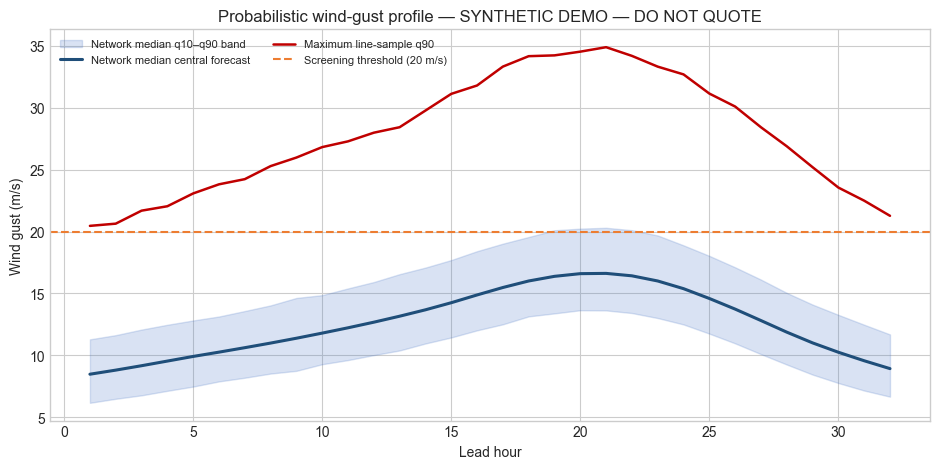

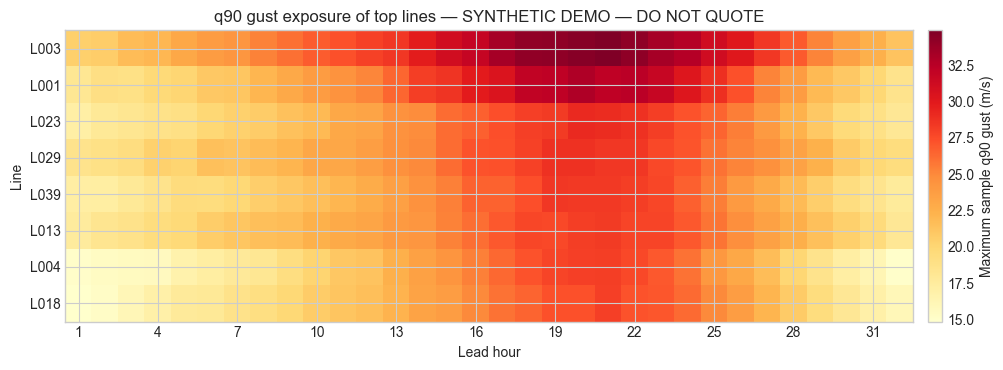

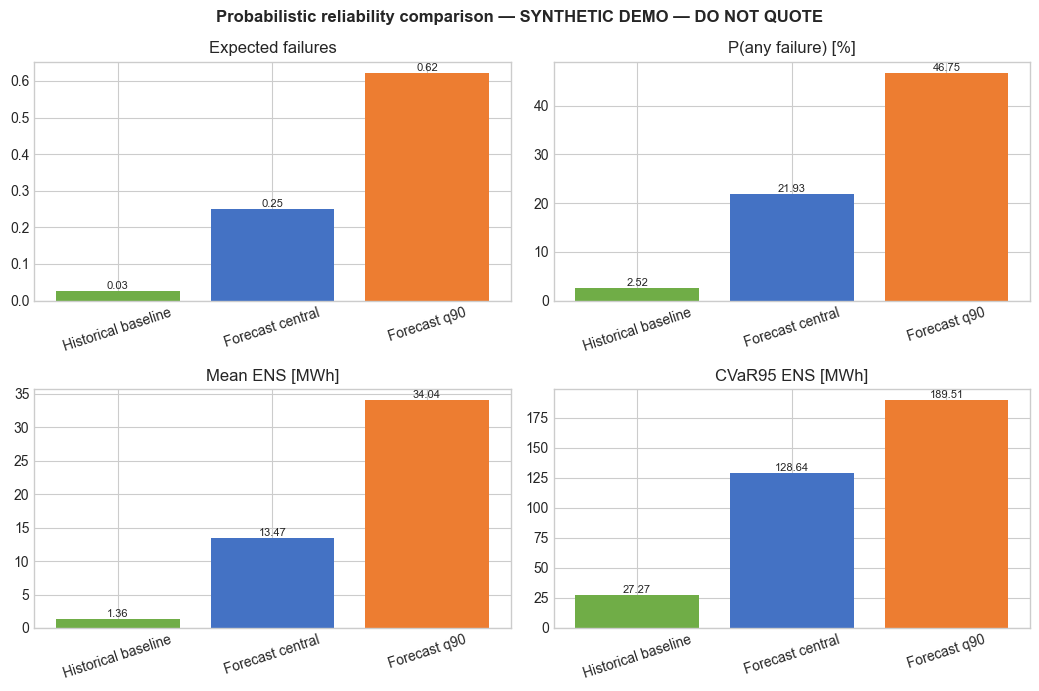

In [6]:
figure_dir = PROJECT_ROOT / CFG.output_dir / f"{CFG.run_label}_{'demo' if CFG.use_synthetic_demo else 'real'}"
figure_dir.mkdir(parents=True, exist_ok=True)

# 1) Network forecast profile.
network_profile = line_hour.groupby("lead_hour").agg(
    q10=("gust_q10_mean_ms", "median"),
    central=("gust_main_mean_ms", "median"),
    q90=("gust_q90_mean_ms", "median"),
    q90_max=("gust_q90_max_ms", "max"),
).reset_index()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.fill_between(network_profile["lead_hour"], network_profile["q10"], network_profile["q90"], alpha=0.20, color="#4472C4", label="Network median q10–q90 band")
ax.plot(network_profile["lead_hour"], network_profile["central"], color="#1F4E79", linewidth=2.2, label="Network median central forecast")
ax.plot(network_profile["lead_hour"], network_profile["q90_max"], color="#C00000", linewidth=1.8, label="Maximum line-sample q90")
ax.axhline(CFG.exposure_threshold_ms, color="#ED7D31", linestyle="--", linewidth=1.5, label=f"Screening threshold ({CFG.exposure_threshold_ms:g} m/s)")
ax.set(xlabel="Lead hour", ylabel="Wind gust (m/s)", title=f"Probabilistic wind-gust profile — {data_label}")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
profile_path = figure_dir / "network_wind_profile.png"
fig.savefig(profile_path, dpi=220, bbox_inches="tight")
plt.show()

# 2) Heatmap for the most exposed lines.
heatmap_lines = top_lines["line_id"].tolist()
heatmap = line_hour[line_hour["line_id"].isin(heatmap_lines)].pivot(index="line_id", columns="lead_hour", values="gust_q90_max_ms")
heatmap = heatmap.loc[heatmap.max(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(11.0, max(3.8, 0.43 * len(heatmap))))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(np.arange(len(heatmap)), labels=heatmap.index)
hour_step = max(1, math.ceil(heatmap.shape[1] / 12))
positions = np.arange(0, heatmap.shape[1], hour_step)
ax.set_xticks(positions, labels=heatmap.columns.to_numpy()[positions])
ax.set(xlabel="Lead hour", ylabel="Line", title=f"q90 gust exposure of top lines — {data_label}")
colourbar = fig.colorbar(image, ax=ax, pad=0.015)
colourbar.set_label("Maximum sample q90 gust (m/s)")
fig.tight_layout()
heatmap_path = figure_dir / "top_line_q90_heatmap.png"
fig.savefig(heatmap_path, dpi=220, bbox_inches="tight")
plt.show()

# 3) PRA comparison, when scenario results are available.
risk_path = None
if pra_summary is not None:
    risk_columns = [
        ("expected_line_failures", "Expected failures"),
        ("probability_any_failure_pct", "P(any failure) [%]"),
        ("mean_ens_mwh", "Mean ENS [MWh]"),
        (f"cvar{int(CFG.cvar_confidence * 100)}_ens_mwh", f"CVaR{int(CFG.cvar_confidence * 100)} ENS [MWh]"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0))
    colours = ["#70AD47", "#4472C4", "#ED7D31"]
    for ax, (column, title) in zip(axes.ravel(), risk_columns):
        ax.bar(pra_summary["condition"], pra_summary[column], color=colours[:len(pra_summary)])
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=18)
        for index, value in enumerate(pra_summary[column]):
            ax.text(index, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle(f"Probabilistic reliability comparison — {data_label}", fontweight="bold")
    fig.tight_layout()
    risk_path = figure_dir / "pra_kpi_comparison.png"
    fig.savefig(risk_path, dpi=220, bbox_inches="tight")
    plt.show()


## Save report-ready outputs

The generated LaTeX tables can be included directly with `\input{...}`. For a
real report, use the `_real` output directory and verify the screening
threshold and risk-model assumptions before citing the values.


In [7]:
output_dir = figure_dir
output_dir.mkdir(parents=True, exist_ok=True)


def save_latex_table(frame: pd.DataFrame, path: Path, float_digits: int = 2) -> None:
    """Write a compact booktabs table without optional pandas/Jinja dependencies."""
    def escape(value) -> str:
        if pd.isna(value):
            text = "--"
        elif isinstance(value, (float, np.floating)):
            text = f"{value:.{float_digits}f}"
        else:
            text = str(value)
        replacements = {
            "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
            "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
        }
        return "".join(replacements.get(character, character) for character in text)

    alignment = "l" + "r" * max(0, len(frame.columns) - 1)
    lines = [r"\begin{tabular}{" + alignment + "}", r"\toprule"]
    lines.append(" & ".join(escape(column) for column in frame.columns) + r" \\")
    lines.append(r"\midrule")
    for row in frame.itertuples(index=False, name=None):
        lines.append(" & ".join(escape(value) for value in row) + r" \\")
    lines.extend([r"\bottomrule", r"\end{tabular}"])
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

mapping_table.to_csv(output_dir / "mapping_summary.csv", index=False)
forecast_table.to_csv(output_dir / "forecast_screening_summary.csv", index=False)
top_lines.to_csv(output_dir / "top_exposed_lines.csv", index=False)
line_hour.to_csv(output_dir / "line_hour_indicators.csv", index=False)
save_latex_table(mapping_table, output_dir / "mapping_summary.tex", float_digits=2)
save_latex_table(forecast_table, output_dir / "forecast_screening_summary.tex", float_digits=2)
save_latex_table(top_lines, output_dir / "top_exposed_lines.tex", float_digits=2)

if pra_summary is not None:
    pra_summary.to_csv(output_dir / "pra_summary.csv", index=False)
    save_latex_table(pra_summary, output_dir / "pra_summary.tex", float_digits=3)

summary = {
    "data_label": data_label,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "config": asdict(CFG),
    "input_paths": {"wind": str(WIND_PATH), "pra": str(PRA_PATH)},
    "mapping_metrics": mapping_metrics,
    "forecast_metrics": forecast_metrics,
    "messages": messages,
}
if pra_summary is not None:
    summary["pra_metrics"] = pra_summary.to_dict(orient="records")
with (output_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, ensure_ascii=False)

prefix = "ILLUSTRATIVE SYNTHETIC DEMO — DO NOT QUOTE. " if CFG.use_synthetic_demo else ""
crosswind_sentence = ""
if forecast_metrics["max_crosswind_q90_ms"] is not None:
    crosswind_sentence = (
        f" The maximum transverse q90 gust was {forecast_metrics['max_crosswind_q90_ms']:.1f} m/s "
        f"on line {forecast_metrics['max_crosswind_q90_line']}."
    )
report_text = (
    prefix
    + f"The mapping covered {mapping_metrics['wind_exposed_lines']} wind-exposed lines and "
    f"{mapping_metrics['line_sample_targets']} line-sample targets. "
    f"{mapping_metrics['matched_targets_pct']:.1f}% of targets were matched within "
    f"{CFG.maximum_matching_distance_km:.0f} km; the median and 95th-percentile matching distances "
    f"were {mapping_metrics['median_match_distance_km']:.1f} km and "
    f"{mapping_metrics['p95_match_distance_km']:.1f} km, respectively. Across the "
    f"{mapping_metrics['forecast_horizon_h']}-hour horizon, the maximum q90 gust was "
    f"{forecast_metrics['network_q90_max_ms']:.1f} m/s on line "
    f"{forecast_metrics['network_q90_max_line']} at lead hour "
    f"{forecast_metrics['network_q90_max_lead_hour']}. "
    f"A total of {forecast_metrics['lines_above_threshold']} lines "
    f"({forecast_metrics['lines_above_threshold_pct']:.1f}%) exceeded the "
    f"{CFG.exposure_threshold_ms:.1f} m/s screening threshold, with a maximum persistence of "
    f"{forecast_metrics['maximum_exceedance_persistence_h']} consecutive hours."
    + crosswind_sentence
)
with (output_dir / "report_ready_paragraph.txt").open("w", encoding="utf-8") as handle:
    handle.write(report_text + "\n")

archive_path = Path(shutil.make_archive(str(output_dir), "zip", root_dir=output_dir))

print("\nREPORT-READY PARAGRAPH")
print(report_text)
print("\nSAVED OUTPUTS")
for path in sorted(output_dir.iterdir()):
    if path.is_file():
        print(f" - {path.name}")
print(f" - {archive_path.name} (ZIP bundle)")
print(f"\nOutput directory: {output_dir}")



REPORT-READY PARAGRAPH
ILLUSTRATIVE SYNTHETIC DEMO — DO NOT QUOTE. The mapping covered 46 wind-exposed lines and 322 line-sample targets. 92.9% of targets were matched within 25 km; the median and 95th-percentile matching distances were 8.6 km and 22.1 km, respectively. Across the 32-hour horizon, the maximum q90 gust was 34.9 m/s on line L003 at lead hour 21. A total of 28 lines (60.9%) exceeded the 20.0 m/s screening threshold, with a maximum persistence of 32 consecutive hours. The maximum transverse q90 gust was 34.2 m/s on line L003.

SAVED OUTPUTS
 - forecast_screening_summary.csv
 - forecast_screening_summary.tex
 - line_hour_indicators.csv
 - mapping_summary.csv
 - mapping_summary.tex
 - network_wind_profile.png
 - pra_kpi_comparison.png
 - pra_summary.csv
 - pra_summary.tex
 - report_ready_paragraph.txt
 - summary.json
 - top_exposed_lines.csv
 - top_exposed_lines.tex
 - top_line_q90_heatmap.png
 - swissgrid_2026_demo.zip (ZIP bundle)

Output directory: C:\Users\roberto.rocch

## Using your real exports

1. Set `CFG.use_synthetic_demo` to `False` in the configuration cell.
2. Point `CFG.wind_csv` at the line-sample-hour forecast export.
3. Optionally point `CFG.pra_csv` at Monte Carlo/PRA scenario results.
4. Confirm `maximum_matching_distance_km`, `exposure_threshold_ms`, and
   `cvar_confidence` match the report methodology.
5. Restart the kernel and run all cells.

The final paragraph and tables are generated from the loaded data. If the PRA
file is missing, the notebook saves all forecast/exposure-screening results
but intentionally makes no reliability-impact claim.